# Dice Success Distribution Calculator (Pre-Computed)

**Rules:**
* Roll `N` d20 dice (Max 10).
* Target number `T` (between 2 and 20).
* If roll < `T`, count as 1 success.
* If roll == `T`, count as 2 successes.
* If roll > `T`, count as 0 successes.

This notebook computes the entire statistical distribution array upon initialization (10 Dice * 19 Targets * 20+ Successes). Charting cells below reference this static `ODDS_CACHE` array, simplifying the logic overhead.

In [1]:
import numpy as np

# --- GENERATE STATIC ODDS CACHE ---
ODDS_CACHE = {}

for num_dice in range(1, 11):
    ODDS_CACHE[num_dice] = {}
    for target in range(2, 21):
        ODDS_CACHE[num_dice][target] = {'exact': [], 'cumulative': [], 'stats': {}}
        
        p_0 = (20 - target) / 20.0
        p_1 = (target - 1) / 20.0
        p_2 = 1.0 / 20.0
        
        single_die = np.array([p_0, p_1, p_2])
        poly = np.polynomial.polynomial.polypow(single_die, num_dice)
        
        percentages = poly * 100
        
        # Calculate up to theoretical 20 max successes
        cumul_list = []
        for s in range(21):
            chance_exact = percentages[s] if s < len(percentages) else 0.0
            chance_cumul = np.sum(percentages[s:]) if s < len(percentages) else 0.0
            
            ODDS_CACHE[num_dice][target]['exact'].append(round(chance_exact, 2))
            
            if s == 0:
                ODDS_CACHE[num_dice][target]['cumulative'].append(round(chance_exact, 2))
            else:
                ODDS_CACHE[num_dice][target]['cumulative'].append(round(chance_cumul, 2))
            
            cumul_list.append(chance_cumul)
            
        # Calculate stats
        # The raw exact float average
        raw_avg = sum(s * (p/100) for s, p in enumerate(percentages))
        # Python's built-in round() rounds x.5 to the nearest EVEN integer. 
        # To round traditional x.5 up to x+1, we add a tiny epsilon.
        avg_success = int(round(raw_avg + 0.000001))
        
        idx_75 = min(range(21), key=lambda i: abs(cumul_list[i] - 75.0))
        idx_25 = min(range(21), key=lambda i: abs(cumul_list[i] - 25.0))
        
        ODDS_CACHE[num_dice][target]['stats'] = {'avg': avg_success, 'p75': idx_75, 'p25': idx_25, 'raw_avg': raw_avg}

print("✅ ODDS_CACHE generated successfully in memory.")

✅ ODDS_CACHE generated successfully in memory.


In [2]:
def format_percent(val, is_cumul_zero=False):
    if is_cumul_zero:
        return f"[{val:05.2f}]"
    if val == 0:
        return "0.00%"
    if val < 0.01 and val > 0:
        return "<0.01%"
    return f"{val:.2f}%"

def apply_styling(fmt_str, s, dice, target):
    stats = ODDS_CACHE[dice][target]['stats']
    is_avg = (s == stats['avg'])
    is_quartile = (s == stats['p25'] or s == stats['p75'])
    
    if is_avg and is_quartile:
        # Bold (1), Underline (4), Italic (3)
        return f"\033[1;4;3m{fmt_str}\033[0m"
    elif is_avg:
        # Bold (1), Underline (4)
        return f"\033[1;4m{fmt_str}\033[0m"
    elif is_quartile:
        # Italic (3)
        return f"\033[3m{fmt_str}\033[0m"
    return fmt_str

def print_header(title, header_labels, col_width=8):
    print(title)
    print("=" * (11 + (col_width + 3) * len(header_labels)))
    
    header = f"{'Succes':<8} | "
    for label in header_labels:
        header += f"{label:>{col_width}} | "
        
    print(header)
    print("-" * len(header))
    return len(header)

def render_chart(target_dicelist_pairs, is_cumul=False, max_s=10, col_width=8):
    for s in range(max_s + 1):
        label_str = f"{s}+" if s == 10 and max_s == 10 else str(s)
        bold_l = f"{label_str}"
        row_str = f"{bold_l:<8} | "
        
        for (target, dice) in target_dicelist_pairs:
            if not (1 <= dice <= 10) or not (2 <= target <= 20):
                 row_str += f"{'Error':>{col_width}} | "
                 continue
                 
            arr_type = 'cumulative' if is_cumul else 'exact'
            
            if s < 10 or max_s != 10:
                val = ODDS_CACHE[dice][target][arr_type][s]
            else:
                if is_cumul:
                    val = ODDS_CACHE[dice][target][arr_type][10]
                else:
                    val = sum(ODDS_CACHE[dice][target][arr_type][10:])
            
            fmt = format_percent(val, is_cumul and s == 0)
            fmt_styled = apply_styling(fmt, s, dice, target)
            
            # Unstyled length is needed for exact column padding
            visible_len = len(fmt)
            pad = " " * max(0, col_width - visible_len)
            row_str += f"{pad}{fmt_styled} | "
        print(row_str)

***
## 1. Fixed Target, Array of Dice Pools

In [3]:
def render_success_distribution(dice_array, target):
    dice_array = [d for d in dice_array if 1 <= d <= 10]
    pairs = [(target, d) for d in dice_array]
    labels = [f"{d} Dice" for d in dice_array]
    
    # EXACT %
    hlen = print_header(f"Target Number: {target} (EXACT %)", labels)
    render_chart(pairs)
    print("=" * hlen + "\n")
    
    # CUMULATIVE %
    print_header(f"Target Number: {target} (X OR MORE %)", labels)
    render_chart(pairs, is_cumul=True)
    print("=" * hlen)
    
render_success_distribution([1, 2, 3, 5, 10], 19)

Target Number: 19 (EXACT %)
Succes   |   1 Dice |   2 Dice |   3 Dice |   5 Dice |  10 Dice | 
------------------------------------------------------------------
0        |    5.00% |    0.25% |    0.01% |    0.00% |    0.00% | 
1        |   90.00% |    9.00% |    0.68% |    0.00% |    0.00% | 
2        |    5.00% |   81.50% |   12.19% |    0.10% |    0.00% | 
3        |    0.00% |    9.00% |   74.25% |    1.83% |    0.00% | 
4        |    0.00% |    0.25% |   12.19% |   16.71% |    0.00% | 
5        |    0.00% |    0.00% |    0.68% |   62.71% |    0.00% | 
6        |    0.00% |    0.00% |    0.01% |   16.71% |    0.07% | 
7        |    0.00% |    0.00% |    0.00% |    1.83% |    0.74% | 
8        |    0.00% |    0.00% |    0.00% |    0.10% |    5.12% | 
9        |    0.00% |    0.00% |    0.00% |    0.00% |   21.57% | 
10+      |    0.00% |    0.00% |    0.00% |    0.00% |   72.48% | 

Target Number: 19 (X OR MORE %)
Succes   |   1 Dice |   2 Dice |   3 Dice |   5 Dice |  10 Dice | 
-

***
## 2. Fixed Dice Pool, Array of Target Numbers

In [4]:
def render_targets_distribution(dice, target_array):
    target_array = [t for t in target_array if 2 <= t <= 20]
    pairs = [(t, dice) for t in target_array]
    labels = [f"TAR {t}" for t in target_array]
    
    # EXACT %
    hlen = print_header(f"Rolling {dice} Dice (EXACT %)", labels)
    render_chart(pairs)
    print("=" * hlen + "\n")
    
    # CUMULATIVE %
    print_header(f"Rolling {dice} Dice (X OR MORE %)", labels)
    render_chart(pairs, is_cumul=True)
    print("=" * hlen)
    
render_targets_distribution(5, [5, 10, 15, 20])

Rolling 5 Dice (EXACT %)
Succes   |    TAR 5 |   TAR 10 |   TAR 15 |   TAR 20 | 
-------------------------------------------------------
0        |   23.73% |    3.12% |    0.10% |    0.00% | 
1        |   31.64% |   14.06% |    1.37% |    0.00% | 
2        |   24.79% |   26.88% |    7.75% |    0.00% | 
3        |   12.94% |   28.41% |   22.53% |    0.00% | 
4        |    5.03% |   18.16% |   34.65% |    0.00% | 
5        |    1.48% |    7.25% |   25.71% |   77.38% | 
6        |    0.34% |    1.82% |    6.93% |   20.36% | 
7        |    0.06% |    0.28% |    0.90% |    2.14% | 
8        |    0.01% |    0.03% |    0.06% |    0.11% | 
9        |    0.00% |    0.00% |    0.00% |    0.00% | 
10+      |    0.00% |    0.00% |    0.00% |    0.00% | 

Rolling 5 Dice (X OR MORE %)
Succes   |    TAR 5 |   TAR 10 |   TAR 15 |   TAR 20 | 
-------------------------------------------------------
0        |  [23.73] |  [03.12] |  [00.10] |  [00.00] | 
1        |   76.27% |   96.88% |   99.90% |  100.

***
## 3. 2D Matrix Combination

In [5]:
def render_matrix_comparison(dice_array, target_array):
    dice_array = [d for d in set(dice_array) if 1 <= d <= 10]
    target_array = sorted([t for t in set(target_array) if 2 <= t <= 20])
    col_width = 12
    
    def render_matrix_chart(title, is_cumul):
        print(title)
        labels = [f"TAR {t}" for t in target_array]
        print("=" * (11 + (col_width + 4) * len(labels)))
        
        header = f"{'Dice':<8} | "
        for label in labels:
            header += f"{label:>{col_width+1}} | "
        print(header)
        print("-" * len(header))
        
        for dice in dice_array:
            for s in range(11):
                label_str = f"{s}+" if s == 10 else str(s)
                
                if s == 0:
                    row_str = f"{dice:<8} | "
                else:
                    row_str = f"{' ':<8} | "
                    
                for target in target_array:
                    arr_type = 'cumulative' if is_cumul else 'exact'
                    
                    if s < 10:
                        val = ODDS_CACHE[dice][target][arr_type][s]
                    else:
                        val = sum(ODDS_CACHE[dice][target][arr_type][10:]) if not is_cumul else ODDS_CACHE[dice][target][arr_type][10]
                        
                    fmt = format_percent(val, is_cumul and s == 0)
                    fmt_styled = apply_styling(fmt, s, dice, target)
                    
                    visible_len = len(label_str) + 2 + len(fmt)
                    pad = " " * max(0, col_width + 1 - visible_len)
                    row_str += f"{pad}{label_str}: {fmt_styled} | "
                    
                print(row_str)
            print("-" * len(header))
        print("=" * len(header))
        print("\n")

    render_matrix_chart("Full Distribution Matrix (EXACT %, 0 to 10+ successes)", False)
    render_matrix_chart("Full Distribution Matrix (X OR MORE %, 0 to 10+ successes)", True)

render_matrix_comparison([1, 2, 3, 5, 10], [5, 10, 14, 15, 16, 20])

Full Distribution Matrix (EXACT %, 0 to 10+ successes)
Dice     |         TAR 5 |        TAR 10 |        TAR 14 |        TAR 15 |        TAR 16 |        TAR 20 | 
-----------------------------------------------------------------------------------------------------------
1        |     0: 75.00% |     0: 50.00% |     0: 30.00% |     0: 25.00% |     0: 20.00% |      0: 0.00% | 
         |     1: 20.00% |     1: 45.00% |     1: 65.00% |     1: 70.00% |     1: 75.00% |     1: 95.00% | 
         |      2: 5.00% |      2: 5.00% |      2: 5.00% |      2: 5.00% |      2: 5.00% |      2: 5.00% | 
         |      3: 0.00% |      3: 0.00% |      3: 0.00% |      3: 0.00% |      3: 0.00% |      3: 0.00% | 
         |      4: 0.00% |      4: 0.00% |      4: 0.00% |      4: 0.00% |      4: 0.00% |      4: 0.00% | 
         |      5: 0.00% |      5: 0.00% |      5: 0.00% |      5: 0.00% |      5: 0.00% |      5: 0.00% | 
         |      6: 0.00% |      6: 0.00% |      6: 0.00% |      6: 0.00% |      6

***
## 4. Expected Average Successes (Heatmap)
This visual maps the mathematical expected value for every combination of Dice Pool and Target number. It provides a visual guide to the "power curve" of a character scaling stats vs. adding dice.

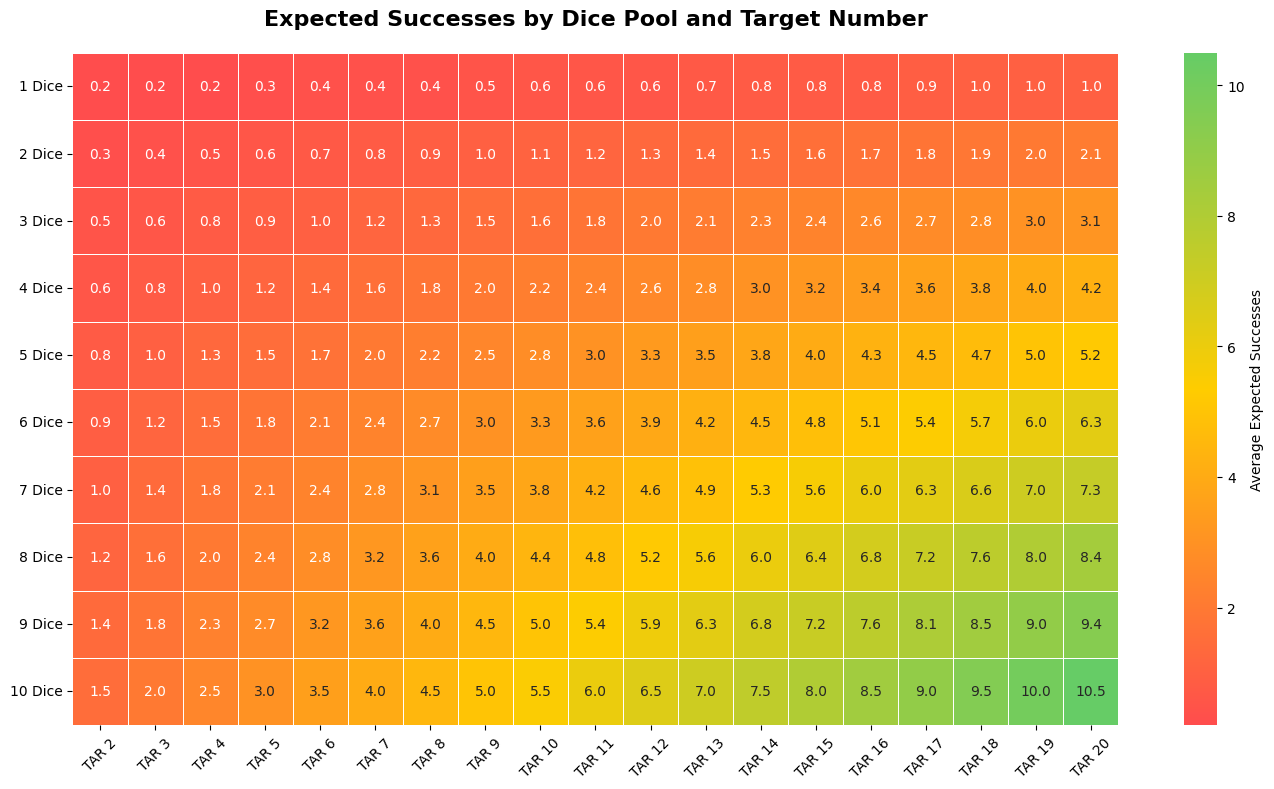

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def render_average_heatmap(dice_range=range(1, 11), target_range=range(2, 21)):
    grid_data = []
    
    for dice in dice_range:
        row = []
        for target in target_range:
            # Grab the raw float expected value and round locally to 1 decimal
            avg_successes = round(ODDS_CACHE[dice][target]['stats']['raw_avg'], 1)
            row.append(avg_successes)
        grid_data.append(row)
        
    # Convert to Pandas DataFrame specifically for easy Seaborn rendering
    df = pd.DataFrame(grid_data, index=[f"{d} Dice" for d in dice_range], columns=[f"TAR {t}" for t in target_range])
    
    plt.figure(figsize=(14, 8))
    
    # Custom RPG-style color map (Red for low success, Yellow mid, Green high)
    cmap = LinearSegmentedColormap.from_list(
        name='rpg_power',
        colors=['#ff4d4d', '#ffcc00', '#66cc66']
    )
    
    # Render Heatmap
    ax = sns.heatmap(
        df, 
        annot=True,     # Show the numbers in the boxes
        fmt=".1f",      # Format as float with 1 decimal place
        cmap=cmap,      
        linewidths=.5,  # Gridlines
        cbar_kws={'label': 'Average Expected Successes'}
    )
    
    ax.set_title("Expected Successes by Dice Pool and Target Number", pad=20, size=16, weight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

render_average_heatmap()